In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance


# CAPSTONE PROJECT

## Early Signal Emergence in Effort, Skill, and Mastery

## Project Overview

This project examines whether meaningful signals about student outcomes emerge before final course completion.

Using longitudinal assessment data, this project combines exploratory data analysis (EDA) and predictive modeling to study how effort, skill, and mastery evolve over time.

The EDA section examines structural patterns in learning trajectories, while the modeling section evaluates how early those patterns become predictive of final outcomes.

Together, these analyses explore both descriptive and predictive perspectives on intervention timing. 


## Exploratory Data Analysis (EDA)

This section examines aggregate structure in the data before predictive modeling.

The goal is to study patterns in first-attempt work, revisions, mastery growth, effort and skill relationships, and evolving correlations that may suggest early signal emergence.

In [2]:
##########################################
# Initialize EDA Data
##########################################

eda_df = pd.read_csv("student_totals_event_features_MERGED.csv")



##########################################
# EDA Parameters
##########################################

EDA_QUESTIONS_PER_STEP = 32

EDA_TOTAL_STEPS = 14



EDA_N_ASSIGNMENTS = 8


EDA_QUESTIONS_PER_ASSIGNMENT = 64



EDA_TOTAL_EXPECTED = EDA_TOTAL_STEPS * EDA_QUESTIONS_PER_STEP


EDA_TOTAL_AVAILABLE = EDA_N_ASSIGNMENTS * EDA_QUESTIONS_PER_ASSIGNMENT

EDA_MAX_EFFORT = EDA_TOTAL_AVAILABLE / EDA_TOTAL_EXPECTED


## Distribution of New Work

This analysis summarizes the distribution of first-attempt outcomes across all recorded assessment events.

The purpose is to establish a baseline view of how new work is distributed before considering revisions or cumulative mastery.

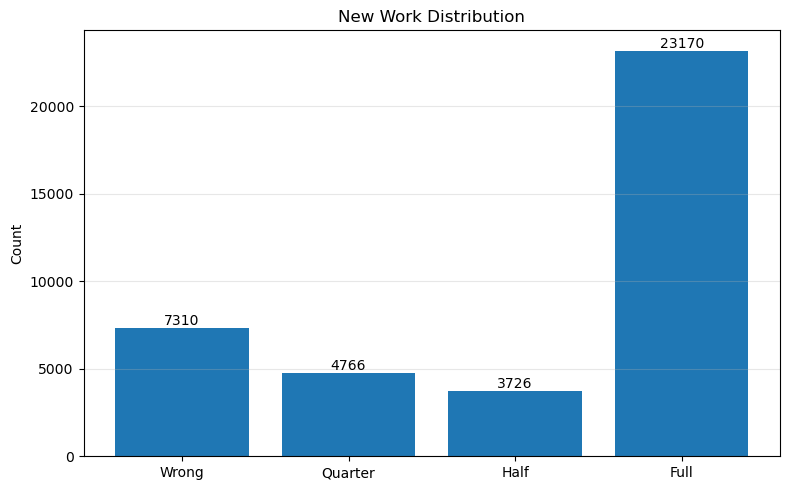

In [3]:
##########################################
##########################################
#
#      DISTRIBUTION OF NEW WORK
#
##########################################
##########################################




##########################################
# Calculate: New Work Distribution
##########################################


new_values = [
    eda_df["new_wrong"].sum(),
    eda_df["new_quarter"].sum(),
    eda_df["new_half"].sum(),
    eda_df["new_full"].sum()
]


new_labels = [
    "Wrong",
    "Quarter",
    "Half",
    "Full"
]



new_work_df = pd.DataFrame({
    "Outcome" : new_labels,
    "Count" : new_values
})






##########################################
# Plot: New Work Distribution
##########################################


fig, ax = plt.subplots(figsize = (8, 5))




bars = ax.bar(new_labels, new_values)

ax.bar_label(bars)


ax.set_title("New Work Distribution")
ax.set_ylabel("Count")

ax.grid(axis = "y", alpha = 0.3)

plt.tight_layout()



plt.savefig(
    "images/new_work_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()




##########################################
# Audit
##########################################



#display(new_work_df)


## New Work Distribution Insights

New work outcomes are dominated by full-credit responses, with smaller proportions of partial-credit and incorrect outcomes.

This suggests that, at the aggregate level, successful first-attempt performance represents a substantial portion of activity.

At the same time, the presence of quarter and half credit outcomes indicates meaningful structured partial understanding rather than a simple correct/incorrect system.

## Distribution of Revisions

This analysis summarizes the frequency of corrections, regressions, and lateral revisions.

The purpose is to examine whether meaningful learning activity occurs through revision behavior, rather than first attempts alone.

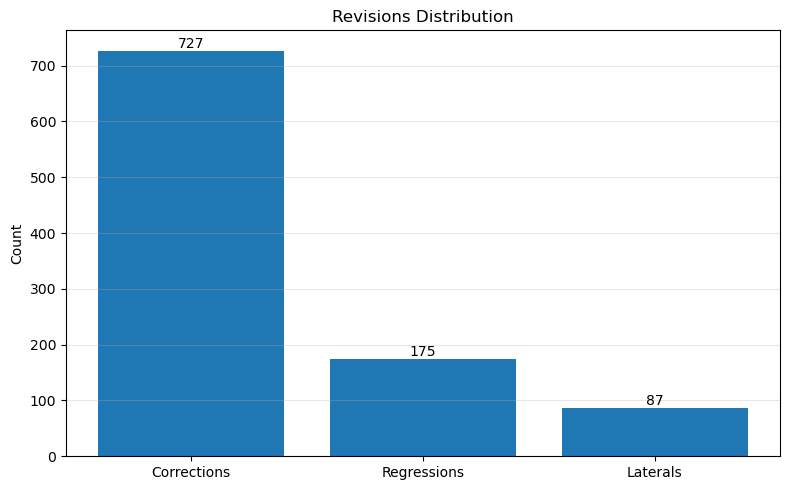

In [4]:
##########################################
##########################################
#
#     DISTRIBUTION OF REVISIONS
#
##########################################
##########################################



##########################################
# Calculate: Revisions Distribution
##########################################


revision_values = [
    eda_df["total_corrections"].sum(),
    eda_df["total_regressions"].sum(),
    eda_df["total_laterals"].sum()
]


revision_labels = [
    "Corrections",
    "Regressions",
    "Laterals"
]


revisions_df = pd.DataFrame({
    "Revision Type" : revision_labels,
    "Count" : revision_values
})




##########################################
# Plot: Revisions Distribution
##########################################


fig, ax = plt.subplots(figsize = (8, 5))




bars = ax.bar(revision_labels, revision_values)

ax.bar_label(bars)

ax.set_title("Revisions Distribution")
ax.set_ylabel("Count")

ax.grid(axis = "y", alpha = 0.3)


plt.tight_layout()



plt.savefig(
    "images/revisions_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit
##########################################

#display(revisions_df)


## Revisions Distribution Insights

Revision activity is dominated by corrections, while regressions and lateral revisions occur less frequently.

This suggests that revision behavior more often reflects productive improvement than deterioration.

Taken together, the results support treating revisions as meaningful learning events rather than simply noise around first-attempt outcomes.

## Spread of Mastery

This analysis examines how the distribution of student mastery evolves over instructional time.

Median performance and interquartile spread are tracked to study both central tendency and dispersion.

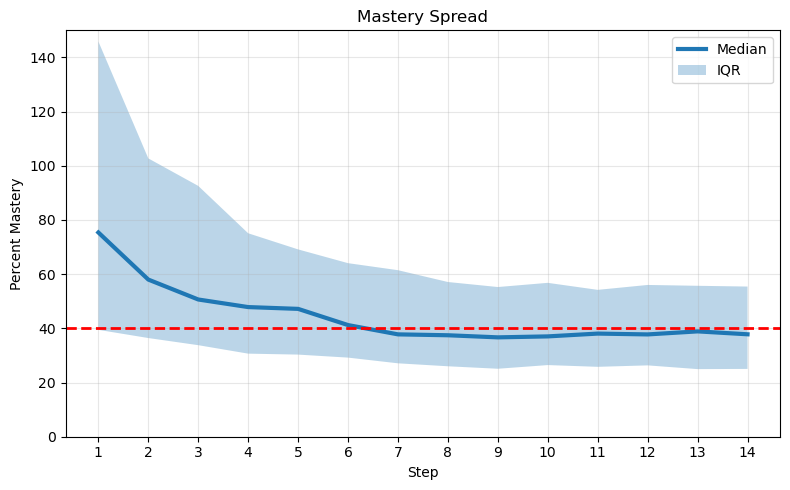

In [5]:
##########################################
##########################################
#
#          SPREAD OF MASTERY
#
##########################################
##########################################




##########################################
# Calculate: Mastery Spread
##########################################


spread_distribution_rows = []


for target_step in range(1, EDA_TOTAL_STEPS + 1):

    spread_cumulative_mastery = 0


    for step in range(1, target_step + 1):

        spread_cumulative_mastery += (
            eda_df[f"new_mastery_step_{step}"].fillna(0) +
            eda_df[f"corr_mastery_step_{step}"].fillna(0) +
            eda_df[f"reg_mastery_step_{step}"].fillna(0)
        )

    spread_mastery_percent = (
        spread_cumulative_mastery / (target_step * EDA_QUESTIONS_PER_STEP)
    ) * 100


    spread_distribution_rows.append({
        "Step" : target_step,
        "Median" : np.median(spread_mastery_percent),
        "Q1" : np.percentile(spread_mastery_percent, 25),
        "Q3" : np.percentile(spread_mastery_percent, 75)
    })

spread_distribution_df = pd.DataFrame(spread_distribution_rows)




##########################################
# Plot: Mastery Spread
##########################################

plt.figure(figsize = (8, 5))


plt.plot(
    spread_distribution_df["Step"],
    spread_distribution_df["Median"],
    linewidth = 3,
    label = "Median"
)


plt.fill_between(
    spread_distribution_df["Step"],
    spread_distribution_df["Q1"],
    spread_distribution_df["Q3"],
    alpha = 0.3,
    label = "IQR"
)

plt.axhline(
    40,
    color = "red",
    linestyle = "--",
    linewidth = 2
)


plt.xlabel("Step")
plt.ylabel("Percent Mastery")
plt.title("Mastery Spread")


plt.grid(alpha = 0.3)

plt.legend()

plt.ylim(0, 150)




plt.xticks(range(1, EDA_TOTAL_STEPS + 1))

plt.tight_layout()


plt.savefig(
    "images/mastery_spread.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit
##########################################

#display(spread_distribution_df)



## Mastery Spread Insights

Median mastery approaches the 40% threshold near Step 7 (approximately halfway through the instructional sequence).

This suggests a possible midpoint transition in aggregate performance growth.

The persistent interquartile spread also indicates substantial heterogeneity in student trajectories, motivating later tiered analyses.

## Distribution of Mastery

This heatmap examines how students distribute across grade-band levels over time.

Rather than summarizing only averages, this view highlights how the broader mastery distribution shifts across instructional steps.

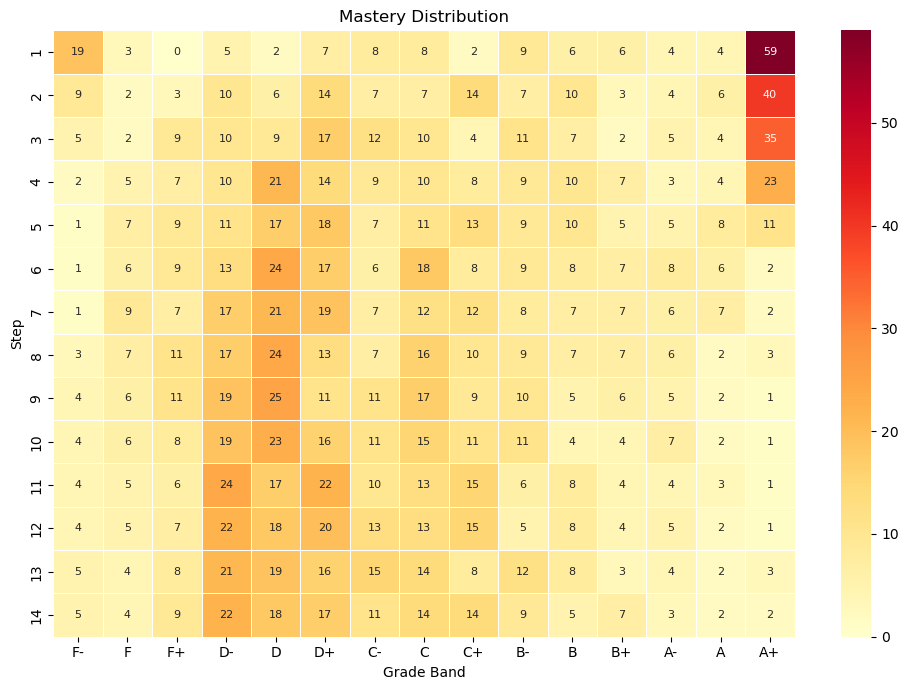

In [6]:
##########################################
##########################################
#
#      DISTRIBUTION OF MASTERY
#
##########################################
##########################################



##########################################
# Calculate: Mastery Distribution
##########################################

heat_grade_band_bins = [
    -np.inf, 
    6.66, 13.32, 19.99,
    26.66, 33.32, 39.99,
    46.66, 53.32, 59.99,
    66.66, 73.32, 79.99,
    86.66, 93.32, np.inf
]


heat_grade_band_labels = [
    "F-", "F", "F+",
    "D-", "D", "D+",
    "C-", "C", "C+",
    "B-", "B", "B+",
    "A-", "A", "A+"
]



heat_grade_band_rows = []


for target_step in range(1, EDA_TOTAL_STEPS + 1):

    heat_cumulative_mastery = 0


    for step in range(1, target_step + 1):

        heat_cumulative_mastery += (
            eda_df[f"new_mastery_step_{step}"].fillna(0) +
            eda_df[f"corr_mastery_step_{step}"].fillna(0) +
            eda_df[f"reg_mastery_step_{step}"].fillna(0)
        )

    heat_mastery_percent = (
        heat_cumulative_mastery / (target_step * EDA_QUESTIONS_PER_STEP)
    ) * 100



    heat_grade_bands = pd.cut(
        heat_mastery_percent,
        bins = heat_grade_band_bins,
        labels = heat_grade_band_labels
    )


    heat_grade_band_counts = (
        heat_grade_bands
        .value_counts()
        .reindex(heat_grade_band_labels, fill_value = 0)
    )

    heat_grade_band_rows.append(heat_grade_band_counts)


heat_grade_band_df = pd.DataFrame(
    heat_grade_band_rows,
    index = range(1, EDA_TOTAL_STEPS + 1)
)




##########################################
# Plot: Mastery Distribution
##########################################



plt.figure(figsize = (10, 7))


sns.heatmap(
    heat_grade_band_df,
    cmap = "YlOrRd",
    annot = True,
    fmt = "d",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 8}
)





plt.title("Mastery Distribution")
plt.xlabel("Grade Band")
plt.ylabel("Step")


plt.tight_layout()



plt.savefig(
    "images/mastery_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()

    
##########################################
# Audit
##########################################

#display(heat_grade_band_df)



## Mastery Distribution Insights

The mastery distribution begins to stabilize around Step 7, with broad structural patterns emerging well before the final steps.

Although individual movement continues, much of the distributional shape appears established by roughly halfway through the sequence.

This supports the broader theme that meaningful performance structure emerges earlier than final outcomes alone might suggest.

## Relationship of Effort and Skill

This analysis models student performance in a two-feature geometry defined by effort and skill.

Iso-grade contours provide a structural view of how these features combine to relate to overall performance.

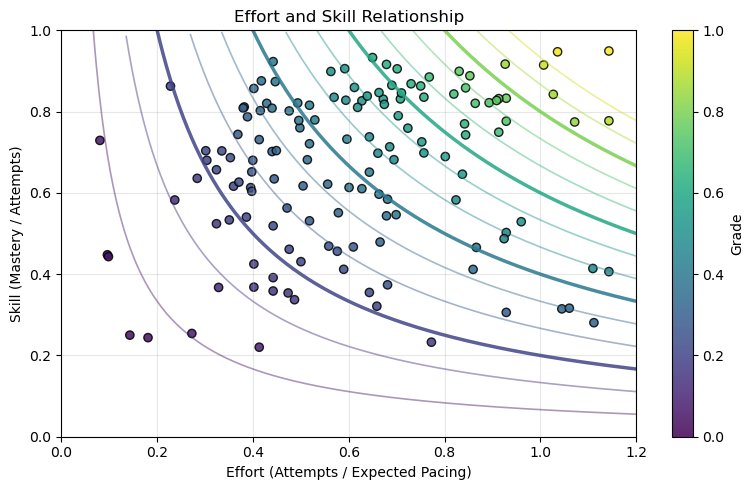

In [7]:
##########################################
##########################################
#
#     RELATIONSHIP OF EFFORT AND SKILL
#
##########################################
##########################################






##########################################
# Calculate: Effort and Skill Relationship
##########################################

effort_skill_records = []


for _, row in eda_df.iterrows():


    cumulative_attempts = 0
    cumulative_mastery = 0



    for step in range(1, EDA_TOTAL_STEPS + 1):


        new_attempt = row[f"new_attempts_step_{step}"]

        new_accuracy = row[f"new_accuracy_step_{step}"]


        if pd.isna(new_attempt):
            new_attempt = 0


        if pd.isna(new_accuracy):
            new_accuracy = 0



        cumulative_attempts += new_attempt

        cumulative_mastery += new_attempt * new_accuracy


    

    effort = cumulative_attempts / EDA_TOTAL_EXPECTED


    
    if cumulative_attempts > 0:
         skill = cumulative_mastery / cumulative_attempts
    else:
        skill = 0





    grade = min(
        cumulative_mastery / EDA_TOTAL_EXPECTED, 
        1
    )


    effort_skill_records.append(
        (effort, skill, grade)
    )


effort_skill_df = pd.DataFrame(
    effort_skill_records,
    columns = ["effort", "skill", "grade"]
)



##########################################
# Plot: Effort and Skill Relationship
##########################################




plt.figure(figsize = (8, 5))





effort_skill_scatter = plt.scatter(
    effort_skill_df["effort"],
    effort_skill_df["skill"],
    c = effort_skill_df["grade"],
    cmap = "viridis",
    vmin = 0,
    vmax = 1,
    edgecolor = "black",
    alpha = 0.85
)


iso_levels = np.array([
    0.0666, 0.1332, 0.1999,
    0.2666, 0.3332, 0.3999,
    0.4666, 0.5332, 0.5999,
    0.6666, 0.7332, 0.7999,
    0.8666, 0.9332
])


major_grade_levels = {
    0.1999, 0.3999, 0.5999, 0.7999
}


effort_values = np.linspace(
    0.01,
    EDA_MAX_EFFORT * 1.05,
    400     
)




for iso_level in iso_levels:

    iso_curve = iso_level / effort_values

    iso_curve[iso_curve > 1] = np.nan


    if iso_level in major_grade_levels:
        iso_line_width = 2.5
    else:
        iso_line_width = 1.2



    if iso_level in major_grade_levels:
        iso_alpha = 0.85
    else:
        iso_alpha = 0.45



    
    plt.plot(
        effort_values,
        iso_curve,
        color = plt.cm.viridis(iso_level),
        linewidth = iso_line_width,
        alpha = iso_alpha
    )






plt.xlim(0, EDA_MAX_EFFORT * 1.05)

plt.ylim(0, 1)


plt.xlabel("Effort (Attempts / Expected Pacing)")

plt.ylabel("Skill (Mastery / Attempts)")

plt.title("Effort and Skill Relationship")

plt.grid(alpha = 0.3)

plt.colorbar(
    effort_skill_scatter,
    label = "Grade"
)

    


plt.tight_layout()



plt.savefig(
    "images/effort_skill_scatter.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()




## Effort and Skill Relationship Insights

This framework is based on new-work behavior only and does not incorporate revision events.

An important implication is that similar final outcomes may arise through different effort-skill combinations.

For example, a student with moderate effort and high skill may achieve outcomes similar to a student with higher effort but lower skill.

This suggests final performance may conceal multiple underlying pathways.

The iso-grade contours also reveal a geometric asymmetry:

Lower grade bands occupy comparatively large regions of the effort-skill space, while high-grade bands occupy much smaller regions despite representing equal percentage-width intervals.

This reflects the increasing joint demands required to sustain higher levels of performance.

## Correlations of Stepwise Features

This analysis tracks how correlations between effort, skill, and final grade evolve over time.

The objective is to examine whether predictive signal strengthens gradually or emerges at identifiable thresholds.

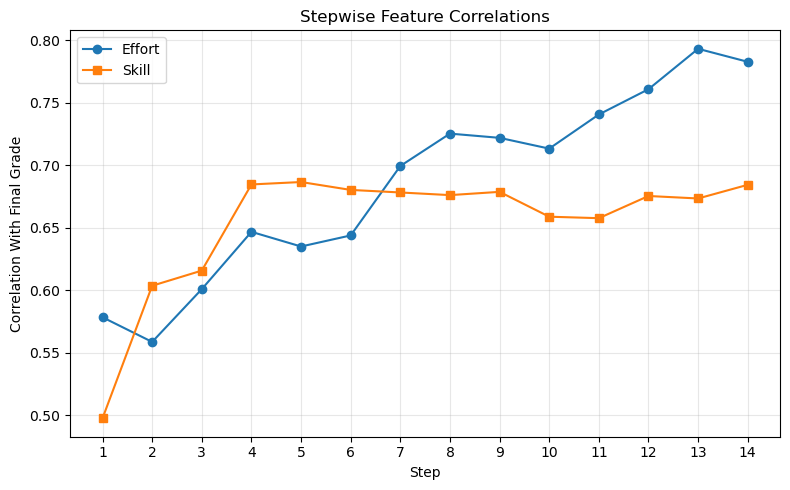

In [8]:
##########################################
##########################################
#
#   CORRELATIONS OF STEPWISE FEATURES
#
##########################################
##########################################



##########################################
# Calculate: Stepwise Feature Correlations
##########################################






final_grade = (
    0.25 * eda_df["final_quarter"] +
    0.50 * eda_df["final_half"] + 
    1.00 * eda_df["final_full"]
) / (EDA_TOTAL_STEPS * EDA_QUESTIONS_PER_STEP)








stepwise_correlation_rows = []


for target_step in range(1, EDA_TOTAL_STEPS + 1):

    cumulative_attempts = 0

    cumulative_mastery = 0


    for step in range(1, target_step + 1):




        new_attempt = eda_df[f"new_attempts_step_{step}"].fillna(0)

        new_accuracy = eda_df[f"new_accuracy_step_{step}"].fillna(0)


        cumulative_attempts += new_attempt

        cumulative_mastery += new_attempt * new_accuracy



    effort = (cumulative_attempts / (target_step * EDA_QUESTIONS_PER_STEP))

    skill = (cumulative_mastery / cumulative_attempts.replace(0, np.nan)).fillna(0)

    stepwise_correlation_rows.append({
        "Step" : target_step,
        "Effort Correlation" : effort.corr(final_grade),
        "Skill Correlation" : skill.corr(final_grade)
    })





stepwise_correlation_df = pd.DataFrame(stepwise_correlation_rows)




##########################################
# Plot: Stepwise Feature Correlations
##########################################        

plt.figure(figsize = (8, 5))


plt.plot(
    stepwise_correlation_df["Step"],
    stepwise_correlation_df["Effort Correlation"],
    linestyle = "-",
    marker = "o",
    label = "Effort"
)



plt.plot(
    stepwise_correlation_df["Step"],
    stepwise_correlation_df["Skill Correlation"],
    linestyle = "-",
    marker = "s",
    label = "Skill"
)





plt.xlabel("Step")

plt.ylabel("Correlation With Final Grade")



plt.xticks(range(1, EDA_TOTAL_STEPS + 1))


plt.title("Stepwise Feature Correlations")

plt.grid(alpha = 0.3)

plt.legend()




plt.tight_layout()


plt.savefig(
    "images/stepwise_feature_correlations.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()


##########################################
# Audit
##########################################  



#display(stepwise_correlation_df)




## Stepwise Feature Correlations Insights

Both effort and skill correlate strongly with the final grade throughout the sequence.

Beginning near Step 7, effort correlations begin to separate modestly from skill correlations and remain generally stronger thereafter.

This provides an exploratory counterpart to the later model-based feature influence results. 

## EDA Summary

Across the exploratory analyses, several patterns emerge:

- First-attempt outcomes are dominated by full credit, while revisions are primarily corrective.

- Aggregate mastery structure begins to stabilize around Step 7.

- Effort and skill define multiple pathways to similar final outcomes.

- Correlation structure suggests effort begins separating from skill around mid-course.

Together, these findings motivate the predictive analyses that follow.

## Predictive Modeling

This section evaluates whether the structural patterns observed in EDA translate into measurable predictive signal.

Regression models are used to study signal emergence over time, feature influence, and differences across performance tiers.

In [9]:
##########################################
##########################################
#
#         HELPER FUNCTIONS
#
##########################################
##########################################




##########################################
# Global Parameters
##########################################


QUESTIONS_PER_STEP = 32





def initialize(filepath):


    ##########################################
    # Read File
    ##########################################
    df = pd.read_csv(filepath)


    ##########################################
    # Find Step Columns
    ##########################################

    
    step_columns = []

    for column in df.columns:

        if "new_attempts_step_" in column:

            step_columns.append(column)


    ##########################################
    # Extract Step Numbers
    ##########################################

        
    step_numbers = []

    for column in step_columns:

        step_num = int(
            column.split("_")[-1]
        )

        step_numbers.append(
            step_num
        )


    ##########################################
    # Maximum Step
    ##########################################
    
    max_step = max(
        step_numbers
    )

    return df, max_step









def build_target_continuous(df, max_step):

    ##########################################
    # Calculate Final Mastery
    ##########################################
    

    final_mastery = (

        0.25 * df["final_quarter"] +
        0.50 * df["final_half"] +
        1.00 * df["final_full"]
    )


    ##########################################
    # Calculate Final Expectation
    ##########################################    

    final_expectation = (
        max_step * QUESTIONS_PER_STEP
    )



    ##########################################
    # Build Continuous Target
    ##########################################   
    
    y = (
        final_mastery / final_expectation
    )


    y = y.fillna(0)

    

    return y

    




def build_split_continuous(df, y):


    ##########################################
    # Train-Test Split
    ##########################################   
    
    df_train, df_test, y_train, y_test = train_test_split(

        df, 
        y, 
        test_size = 0.2,
        random_state = 42
    )

    return df_train, df_test, y_train, y_test








def build_features(df, step):


    ##########################################
    # Calculate Cumulative Attempts
    ##########################################   
    
    attempts = 0

    for i in range(1, step + 1):

        attempts += (
            df[f"new_attempts_step_{i}"]
        )
    


    ##########################################
    # Calculate Cumulative Mastery
    ##########################################   
    
    mastery = 0

    for i in range(1, step + 1):

        mastery += (
            df[f"new_attempts_step_{i}"] *
            df[f"new_accuracy_step_{i}"].fillna(0)
        )
            




    ##########################################
    # Calculate Effort 
    ##########################################   
    
    effort = (
        attempts / (step * QUESTIONS_PER_STEP)
    )


    ##########################################
    # Calculate Skill 
    ##########################################   

    
    skill = (
            mastery / attempts.replace(0, np.nan)
        ).fillna(0)



    ##########################################
    # Return Features
    ##########################################   
    
    return pd.DataFrame({
        "effort" : effort,
        "skill" : skill
    })








## Ridge Model Selection

This analysis uses cross-validated ridge regression with polynomial features to study bias-variance tradeoffs and identify a stable predictive model.

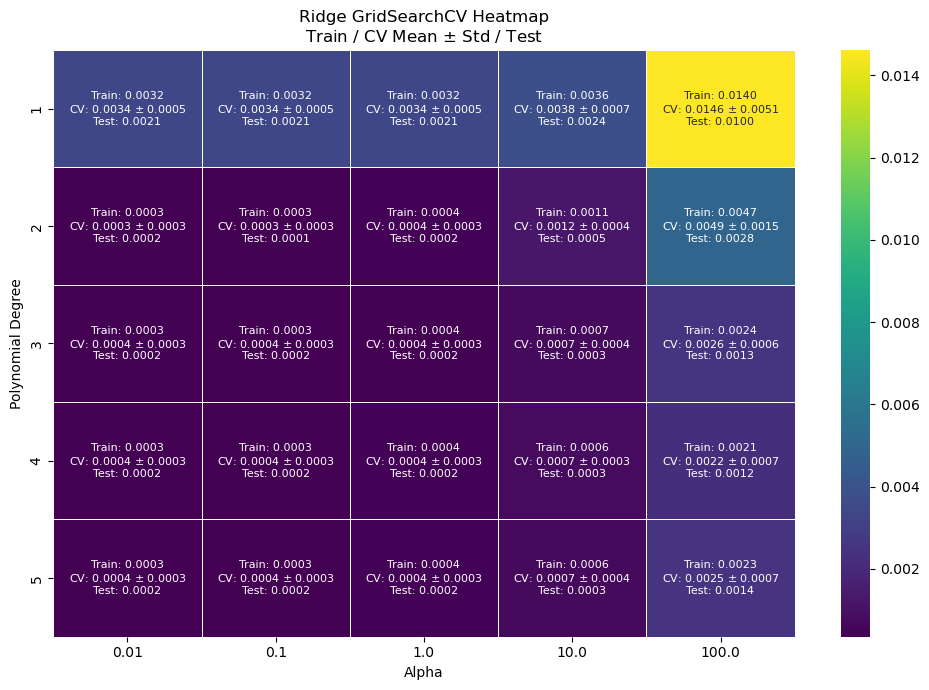


Best Parameters
{'polynomial_features__degree': 2, 'ridge__alpha': 0.01}


In [10]:
##########################################
##########################################
#
#          RIDGE REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#            CALCULATION
#
##########################################
##########################################





##########################################
# Parameters
##########################################


degrees = [1, 2, 3, 4, 5]

alphas = [0.01, 0.1, 1, 10, 100]


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))



##########################################
# Features
##########################################

X_train = build_features(df_train, max_step)


X_test = build_features(df_test, max_step)




##########################################
# Pipeline
##########################################


lin_reg_grid_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("ridge", Ridge())
])




##########################################
# Parameter Grid
##########################################

param_grid = {
    "polynomial_features__degree" : degrees,
    "ridge__alpha" : alphas
}


##########################################
# Grid Search
##########################################


lin_reg_grid_search = GridSearchCV(
    estimator = lin_reg_grid_pipeline,
    param_grid = param_grid,
    scoring = "neg_mean_squared_error",
    cv = 5,
    return_train_score = True
)



lin_reg_grid_search.fit(X_train, y_train)



##########################################
# Save Results
##########################################

ridge_heat_df = pd.DataFrame(
    lin_reg_grid_search.cv_results_
)



ridge_heat_df["Train MSE"] = -ridge_heat_df["mean_train_score"]


ridge_heat_df["CV MSE"] = -ridge_heat_df["mean_test_score"]


ridge_heat_df["CV Std"] = ridge_heat_df["std_test_score"]





##########################################
# Calculate Grid Test MSE
##########################################


ridge_test_mse_list = []


for _, row in ridge_heat_df.iterrows():

    degree = row["param_polynomial_features__degree"]

    alpha = row["param_ridge__alpha"]


    lin_reg_grid_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])

    lin_reg_grid_model.fit(X_train, y_train)

    grid_test_preds = lin_reg_grid_model.predict(X_test)

    test_mse = mean_squared_error(
        y_test,
        grid_test_preds
    )

    ridge_test_mse_list.append(
        test_mse
    )






ridge_heat_df["Test MSE"] = ridge_test_mse_list






##########################################
##########################################
#
#          RIDGE REGRESSION
#
#        GRIDSEARCHCV HEATMAP
#
#               PLOT
#
##########################################
##########################################


##########################################
# Create Heatmap Labels
##########################################


ridge_heat_df["label"] = ridge_heat_df.apply(
    lambda row: (
        f"Train: {row['Train MSE']:.4f}\n"
        f"CV: {row['CV MSE']:.4f} $\pm$ {row['CV Std']:.4f}\n"
        f"Test: {row['Test MSE']:.4f}"
    ),
    axis = 1
)




##########################################
# Pivot Tables
##########################################


ridge_mean_table = ridge_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_ridge__alpha",
    values = "CV MSE"
)


ridge_label_table = ridge_heat_df.pivot(
    index = "param_polynomial_features__degree",
    columns = "param_ridge__alpha",
    values = "label"
)



##########################################
# Heatmap
##########################################



plt.figure(figsize = (10, 7))


sns.heatmap(
    ridge_mean_table,
    annot = ridge_label_table,
    fmt = "",
    cmap = "viridis",
    linewidths = 0.5,
    linecolor = "white",
    annot_kws = {"fontsize" : 8}
)



plt.title(
    "Ridge GridSearchCV Heatmap\n"
    "Train / CV Mean $\pm$ Std / Test"
)


plt.xlabel("Alpha")
plt.ylabel("Polynomial Degree")



plt.tight_layout()



plt.savefig(
    "images/ridge_model_selection.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()







##########################################
# Audit 
##########################################


#display(
#    ridge_heat_df
#    .set_index(
#        [
#            "param_polynomial_features__degree",
#            "param_ridge__alpha"
#        ]
#    )
#    [
#        [
#            "Train MSE", 
#            "CV MSE",
#            "CV Std",
#            "Test MSE"
#        ]
#    ]
#    .sort_values(
#        by = "CV MSE"
#    )
#)


print("\nBest Parameters")
print(lin_reg_grid_search.best_params_)








## Ridge Model Selection Insights

The GridSearchCV heatmap suggests that moderate regularization with low-degree polynomial features provides the strongest balance of fit and stability.

At degree = 2, alpha = 0.01 and alpha = 0.1 produced essentially equivalent cross-validation performance, with alpha = 0.01 selected by GridSearchCV.

Because alpha = 0.1 provided comparable performance while using slightly stronger regularization, it was chosen as a near-optimal but slightly more stable model.

Higher-degree models produced diminishing gains and greater variability, suggesting additional complexity was not necessary.

## Global Prediction Diagnostics

This analysis evaluates global fit through predicted-versus-actual and residual diagnostics.

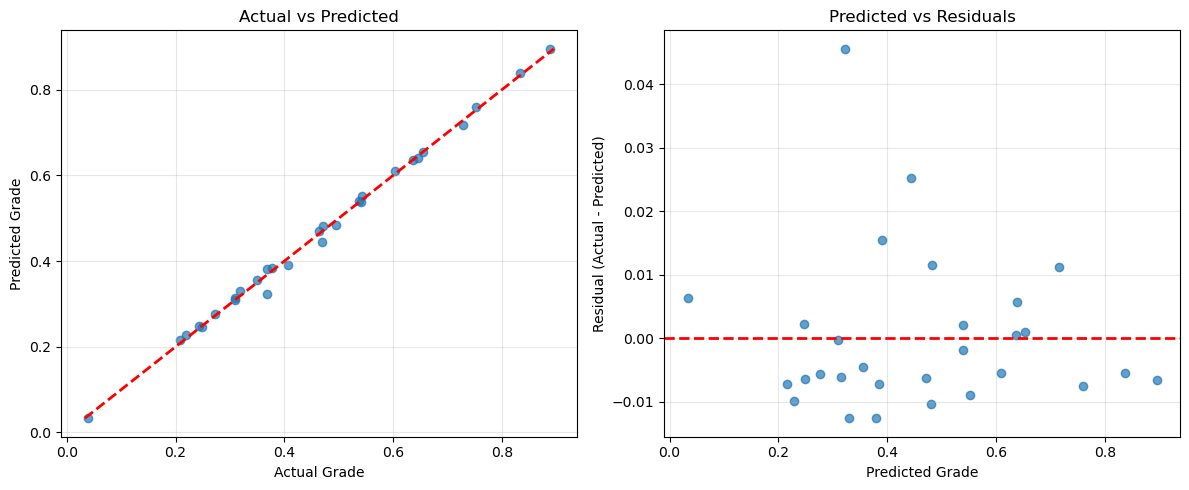

In [11]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#    FIT AND RESIDUAL DIAGNOSTICS
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))



##########################################
# Features
##########################################

X_train = build_features(df_train, max_step)


X_test = build_features(df_test, max_step)






##########################################
# Model
##########################################

lin_reg_global_pipeline = Pipeline([
    ("polynomial_features", PolynomialFeatures(
        degree = degree,
        include_bias = False
    )),
    ("standard_scaler", StandardScaler()),
    ("ridge", Ridge(alpha = alpha))
])


lin_reg_global_pipeline.fit(X_train, y_train)




##########################################
# Calculate MSE
##########################################


train_preds = lin_reg_global_pipeline.predict(X_train)

test_preds = lin_reg_global_pipeline.predict(X_test)


train_mse = mean_squared_error(
    y_train,
    train_preds
)



test_mse = mean_squared_error(
    y_test,
    test_preds
)


global_residuals = y_test - test_preds




##########################################
# Save Results
##########################################


lin_reg_global_results_df = pd.DataFrame({
    "Global Actual Grade" : y_test,
    "Global Predicted Grade" : test_preds,
    "Global Residuals" : global_residuals,
})




##########################################
# Save Audit Results
##########################################


lin_reg_global_audit_df = pd.DataFrame({
    "Metric" : [
        "Train MSE",
        "Test MSE"
    ],
    "Value" : [
        train_mse, 
        test_mse
    ]
})








##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#    FIT AND RESIDUAL DIAGNOSTICS
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            PLOT
#
##########################################
##########################################



##########################################
# Load Results
##########################################

lin_reg_global_preds = lin_reg_global_results_df["Global Predicted Grade"]

lin_reg_global_actual = lin_reg_global_results_df["Global Actual Grade"]

lin_reg_global_residuals = lin_reg_global_results_df["Global Residuals"]






fig, axes = plt.subplots(1, 2, figsize = (12, 5))




##########################################
# Actual vs Predicted
##########################################



ax = axes[0]

ax.scatter(lin_reg_global_actual, lin_reg_global_preds, alpha = 0.7)


min_val = min(lin_reg_global_preds.min(), lin_reg_global_actual.min())

max_val = max(lin_reg_global_preds.max(), lin_reg_global_actual.max())





ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color = "red",
    linestyle = "--",
    linewidth = 2
)


ax.set_title("Actual vs Predicted")
ax.set_xlabel("Actual Grade")
ax.set_ylabel("Predicted Grade")
ax.grid(alpha = 0.3)





##########################################
# Predicted vs Residuals
##########################################


ax = axes[1]


ax.scatter(lin_reg_global_preds, lin_reg_global_residuals, alpha = 0.7)




ax.axhline(
    0,
    color = "red",
    linestyle = "--",
    linewidth = 2
)



ax.set_title("Predicted vs Residuals")
ax.set_xlabel("Predicted Grade")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.grid(alpha = 0.3)


plt.tight_layout()


plt.savefig(
    "images/global_prediction_diagnostics.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()




##########################################
# Audit
##########################################





#display(
#    lin_reg_global_audit_df
#    .set_index("Metric")
#    [
#        [
#            "Value"
#        ]
#    ]
#)






## Global Prediction Insights

Predicted and actual grades align closely, suggesting the model captures substantial structure in the outcome.

Residuals show limited systematic pattern, supporting model adequacy across much of the response range.

Taken together, these diagnostics support using the selected ridge model for stepwise analyses.

## Stepwise Prediction Performance (R$^2$)

This analysis examines how predictive signal develops over instructional time.

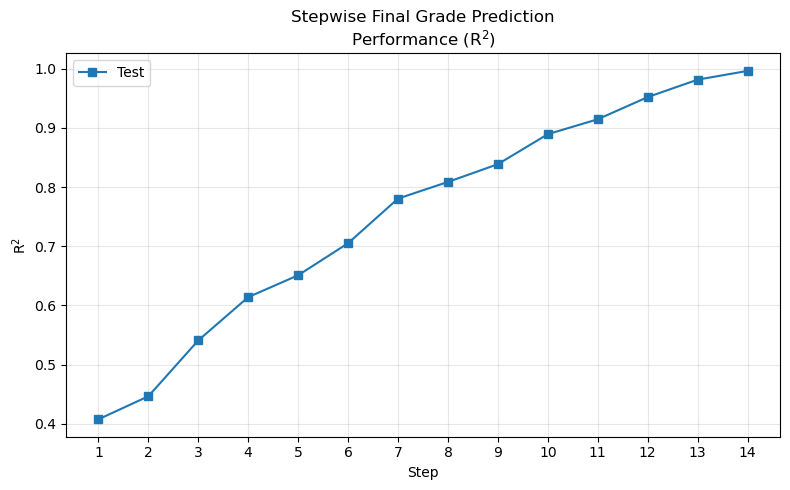

In [12]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))







##########################################
# Storage
##########################################

lin_reg_step_r2_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    lin_reg_step_r2_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_step_r2_model.fit(X_train, y_train)





    
    ##########################################
    # Calculate R2
    ##########################################


    train_preds = lin_reg_step_r2_model.predict(X_train)

    test_preds = lin_reg_step_r2_model.predict(X_test)


    train_r2 = r2_score(y_train, train_preds)

    test_r2 = r2_score(y_test, test_preds)


    ##########################################
    # Store Results
    ##########################################
    


    lin_reg_step_r2_results_list.append({
        "Step" : step,
        "Train R2" : train_r2,
        "Test R2" : test_r2
    })




##########################################
# Save Results
##########################################

lin_reg_step_r2_df = pd.DataFrame(lin_reg_step_r2_results_list)




##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#               (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





plt.figure(figsize = (8, 5))


##########################################
# Plot Stepwise R2
##########################################


#plt.plot(
#    lin_reg_step_r2_df["Step"],
#    lin_reg_step_r2_df["Train R2"],
#    linestyle = "--",
#    marker = "o",
#    label = "Train"
#)




plt.plot(
    lin_reg_step_r2_df["Step"],
    lin_reg_step_r2_df["Test R2"],
    linestyle = "-",
    marker = "s",
    label = "Test"
)



##########################################
# Labels
##########################################

plt.xlabel("Step")

plt.ylabel("R$^2$")

plt.title(
    "Stepwise Final Grade Prediction\n"
    "Performance (R$^2$)"
)

    
plt.xticks(range(1, max_step + 1))






##########################################
# Final Plot Formatting
##########################################


plt.legend()
plt.grid(alpha = 0.3)




plt.tight_layout()


plt.savefig(
    "images/stepwise_r2.png",
    dpi = 300,
    bbox_inches = "tight"
)



plt.show()



##########################################
# Audit
##########################################

#display(
#    lin_reg_step_r2_df
#    .set_index("Step")
#    [
#        [
#            "Train R2",
#            "Test R2"
#        ]
#    ]
#)






## Stepwise Prediction Insights

Predictive signal strengthens steadily across steps.

By approximately Step 7 (halfway through the sequence), the model explains roughly 78% of variation in final grade.

By Step 10, explanatory power exceeds 88%, suggesting strong predictive signal emerges well before final outcomes are observed.

## Stepwise Feature Influence (Permutation Importance)

This analysis evaluates how effort and skill influence evolves over time. 

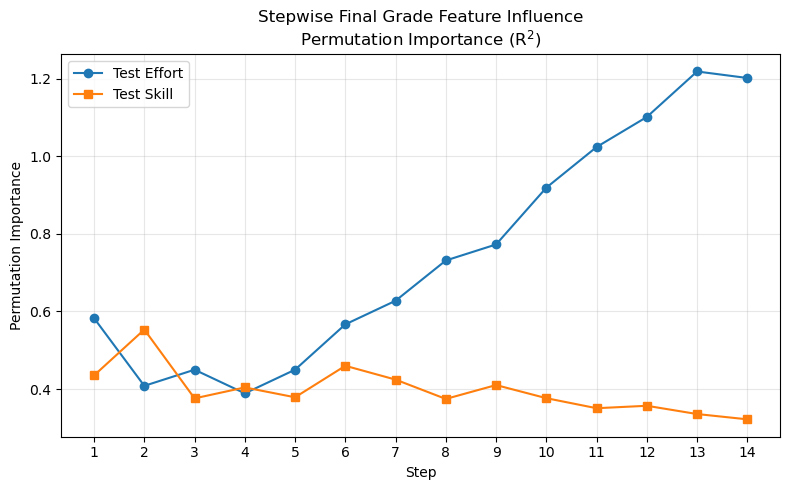

In [13]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################







##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1



##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))







##########################################
# Storage
##########################################

lin_reg_step_pi_results_list = []





##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)


    ##########################################
    # Model
    ##########################################


    lin_reg_step_pi_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_step_pi_model.fit(X_train, y_train)


    ##########################################
    # Calculate Permutation Importance
    ##########################################


    perm_train = permutation_importance(
        lin_reg_step_pi_model,
        X_train,
        y_train,
        n_repeats = 10,
        random_state = 42,
        scoring = "r2"
    )

    

    perm_test = permutation_importance(
        lin_reg_step_pi_model,
        X_test,
        y_test,
        n_repeats = 10,
        random_state = 42,
        scoring = "r2"
    )
    

    ##########################################
    # Store Results
    ##########################################
    


    lin_reg_step_pi_results_list.append({
        "Step" : step,
        "Train Effort PI" : perm_train.importances_mean[0],
        "Train Skill PI" : perm_train.importances_mean[1],
        "Test Effort PI" : perm_test.importances_mean[0],
        "Test Skill PI" : perm_test.importances_mean[1]
    })



##########################################
# Save Results
##########################################

lin_reg_step_pi_df = pd.DataFrame(lin_reg_step_pi_results_list)








##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#      STEPWISE MODEL PERFORMANCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################








plt.figure(figsize = (8, 5))



##########################################
# Plot Stepwise PI
##########################################




#plt.plot(
#    lin_reg_step_pi_df["Step"],
#    lin_reg_step_pi_df["Train Effort PI"],
#    linestyle = "--",
#    marker = "o",
#    label = "Train Effort"
#)



plt.plot(
    lin_reg_step_pi_df["Step"],
    lin_reg_step_pi_df["Test Effort PI"],
    linestyle = "-",
    marker = "o",
    label = "Test Effort"
)




#plt.plot(
#    lin_reg_step_pi_df["Step"],
#    lin_reg_step_pi_df["Train Skill PI"],
#    linestyle = "--",
#    marker = "s",
#    label = "Train Skill"
#)



plt.plot(
    lin_reg_step_pi_df["Step"],
    lin_reg_step_pi_df["Test Skill PI"],
    linestyle = "-",
    marker = "s",
    label = "Test Skill"
)






##########################################
# Labels
##########################################


plt.xlabel("Step")

plt.ylabel("Permutation Importance")

plt.title(
    "Stepwise Final Grade Feature Influence\n"
    "Permutation Importance (R$^2$)"
)



    
plt.xticks(range(1, max_step + 1))

##########################################
# Final Plot Formatting
##########################################


plt.legend()




plt.grid(alpha = 0.3)

plt.tight_layout()


plt.savefig(
    "images/stepwise_pi.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit
##########################################

#display(
#    lin_reg_step_pi_df
#    .set_index("Step")
#    [
#        [
#            "Train Effort PI",
#            "Train Skill PI",
#            "Test Effort PI",
#            "Test Skill PI"
#        ]
#    ]
#)






## Stepwise Feature Influence Insights

Effort and skill begin with comparable influence.

Around Step 7, effort begins to separate more clearly from skill, and that separation widens over later steps.

This suggests pacing-related behavior may become increasingly predictive as instruction progresses.

## Tiered Prediction Performance (R$^2$)

This analysis examines whether predictive signal emerges differently across performance tiers.

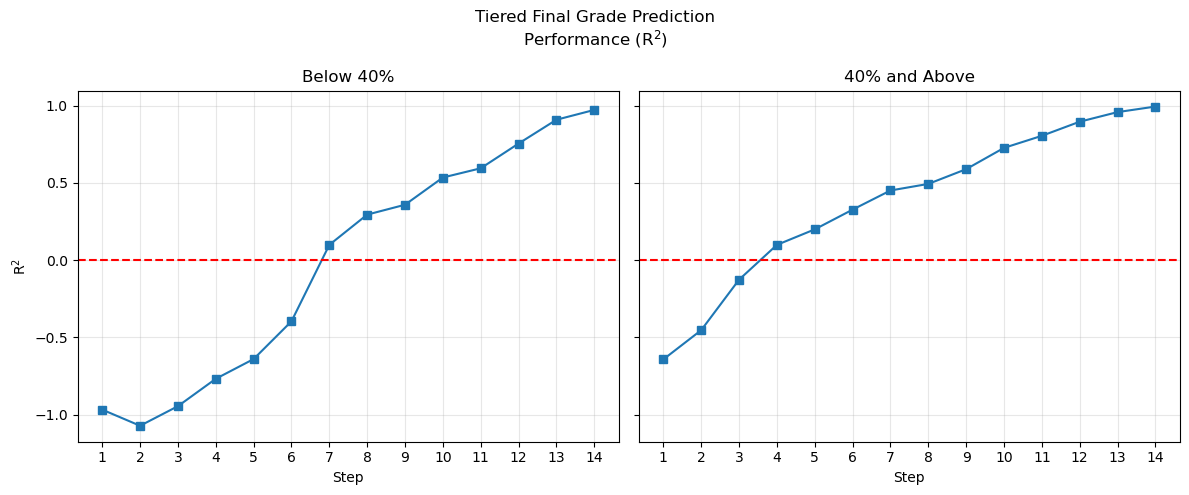

In [14]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################






##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)



##########################################
# Create Tiers
##########################################

df["tier"] = np.where(
    y < 0.4,
    "Below 40%",
    "40% and Above"
)




##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))



##########################################
# Storage
##########################################


lin_reg_tier_r2_results_list = []




##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)





    ##########################################
    # Model
    ##########################################


    lin_reg_tier_r2_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_tier_r2_model.fit(X_train, y_train)


    test_preds = lin_reg_tier_r2_model.predict(X_test)



    ##########################################
    # Calculate Tier R2
    ##########################################

    tier_test = df_test["tier"]


    for tier_label in [
        "Below 40%",
        "40% and Above"
    ]:

        mask_test = (
            tier_test == tier_label
        )




        
        test_r2 = r2_score(
            y_test[mask_test], 
            test_preds[mask_test]
        )

        ##########################################
        # Store Results
        ##########################################


        
        lin_reg_tier_r2_results_list.append({
            "Step" : step, 
            "Tier" : tier_label,
            "Test R2" : test_r2
        })


##########################################
# Save Results
##########################################

lin_reg_tier_r2_df = pd.DataFrame(lin_reg_tier_r2_results_list)







##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#       TIERED STEPWISE PERFORMANCE 
#                (R2)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





##########################################
# Plot Tier R2
##########################################

fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5), 
    sharey = True
)


tiers = [
    "Below 40%",
    "40% and Above"
]





for ax, tier in zip(axes, tiers):

    temp = (
        lin_reg_tier_r2_df[
           lin_reg_tier_r2_df["Tier"] == tier
        ]
    )

    ax.plot(
        temp["Step"],
        temp["Test R2"], 
        linestyle = "-",
        marker = "s"
    )

    ax.axhline(
        0,
        color = "red",
        linestyle = "--"
    )

    ax.set_title(tier)

    ax.set_xlabel("Step")

    ax.grid(alpha = 0.3)


        
    ax.set_xticks(range(1, max_step + 1))
    

    



axes[0].set_ylabel("R$^2$")

plt.suptitle(
    "Tiered Final Grade Prediction\n"
    "Performance (R$^2$)"
)

plt.tight_layout()


plt.savefig(
    "images/tiered_r2.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit Tier R2
##########################################

#display(
#    lin_reg_tier_r2_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = "Test R2"
#    )
#)






## Tiered Signal Emergence Insights

Signal appears to emerge earlier for students at or above 40% than for students below 40%.

For the 40%-and-above tier, positive predictive signal appears around Step 4 (roughly quarter-course).

For the below-40% tier, comparable signal does not emerge until approximately Step 7 (half-course).

The asymmetry has possible implications for intervention timing. 

## Tiered Feature Influence (Permutation Importance)

This analysis examines whether effort and skill influence differ structurally across tiers. 

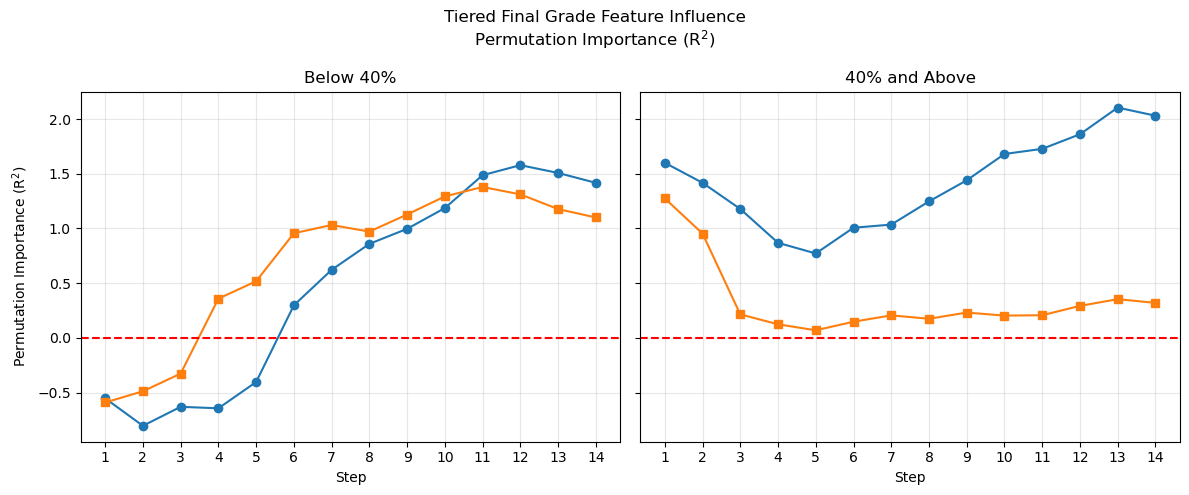

In [15]:
##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     TIERED STEPWISE FEATURE INFLUENCE 
#        (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#            CALCULATION
#
##########################################
##########################################






##########################################
# Parameters
##########################################



degree = 2

alpha = 0.1


##########################################
# Initialize
##########################################

df, max_step = initialize("student_totals_event_features_MERGED.csv")


##########################################
# Target
##########################################

y = build_target_continuous(df, max_step)




##########################################
# Create Tiers
##########################################

df["tier"] = np.where(
    y < 0.4,
    "Below 40%",
    "40% and Above"
)




##########################################
# Split
##########################################

df_train, df_test, y_train, y_test = (build_split_continuous(df, y))



##########################################
# Storage
##########################################


lin_reg_tier_pi_results_list = []




##########################################
# Step Loop
##########################################

for step in range(1, max_step + 1):


    ##########################################
    # Features
    ##########################################

    
    
    X_train = build_features(df_train, step)

    X_test = build_features(df_test, step)





    ##########################################
    # Model
    ##########################################


    lin_reg_tier_pi_model = Pipeline([
        ("polynomial_features", PolynomialFeatures(
            degree = degree,
            include_bias = False
        )),
        ("standard_scaler", StandardScaler()),
        ("ridge", Ridge(
            alpha = alpha
        ))
    ])


    lin_reg_tier_pi_model.fit(X_train, y_train)




    ##########################################
    # Calculate Tier PI
    ##########################################

    tier_test = df_test["tier"]


    for tier_label in [
        "Below 40%",
        "40% and Above"
    ]:

        mask_test = (
            tier_test == tier_label
        )
    
        ##########################################
        # Tier Subset
        ##########################################
        

        X_test_tier = X_test[mask_test]

        y_test_tier = y_test[mask_test]


        perm = permutation_importance(
            lin_reg_tier_pi_model,
            X_test_tier,
            y_test_tier,
            n_repeats = 10,
            random_state = 42,
            scoring = "r2"
        )


        


        ##########################################
        # Store Results
        ##########################################


        
        lin_reg_tier_pi_results_list.append({
            "Step" : step, 
            "Tier" : tier_label,
            "Test Effort PI" : perm.importances_mean[0],
            "Test Skill PI" : perm.importances_mean[1]
        })


##########################################
# Save Results
##########################################

lin_reg_tier_pi_df = pd.DataFrame(lin_reg_tier_pi_results_list)







##########################################
##########################################
#
#       GLOBAL RIDGE REGRESSION
#     TIERED STEPWISE FEATURE INFLUENCE 
#       (PERMUTATION IMPORTANCE)
#
#        POLYNOMIAL DEGREE = 2
#           ALPHA = 0.1
#
#               PLOT
#
##########################################
##########################################





##########################################
# Plot Tier PI
##########################################

fig, axes = plt.subplots(
    1, 2, 
    figsize = (12, 5), 
    sharey = True
)


tiers = [
    "Below 40%",
    "40% and Above"
]





for ax, tier in zip(axes, tiers):

    temp = (
        lin_reg_tier_pi_df[
           lin_reg_tier_pi_df["Tier"] == tier
        ]
    )

    ax.plot(
        temp["Step"],
        temp["Test Effort PI"], 
        linestyle = "-",
        marker = "o",
        label = "Effort"
    )


    ax.plot(
        temp["Step"],
        temp["Test Skill PI"], 
        linestyle = "-",
        marker = "s",
        label = "Skill"
    )
    
    ax.axhline(
        0,
        color = "red",
        linestyle = "--"
    )

    ax.set_title(tier)

    ax.set_xlabel("Step")

    ax.grid(alpha = 0.3)


    
    ax.set_xticks(range(1, max_step + 1))




axes[0].set_ylabel("Permutation Importance (R$^2$)")

plt.suptitle(
    "Tiered Final Grade Feature Influence\n"
    "Permutation Importance (R$^2$)"
)

plt.tight_layout()


plt.savefig(
    "images/tiered_pi.png",
    dpi = 300,
    bbox_inches = "tight"
)


plt.show()



##########################################
# Audit Effort PI
##########################################

#display(
#    lin_reg_tier_pi_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = "Test Effort PI"
#    )
#)


##########################################
# Audit Skill PI
##########################################

#display(
#    lin_reg_tier_pi_df
#    .pivot(
#        index = "Step",
#        columns = "Tier",
#        values = "Test Skill PI"
#    )
#)



## Tiered Feature Influence Insights

For students at or above 40%, effort exhibits consistently greater influence than skill.

For students below 40%, effort and skill remain much closer in magnitude, with less pronounced separation.

This suggests potentially different structural dynamics may characterize successful versus struggling trajectories. 

## MODELING SUMMARY

Across the modeling analyses, three patterns emerge:

- Predictive signal strengthens surprisingly early.

- Effort and skill begin similarly, but separate over time.

- Signal emergence differs across performance tiers.

Together, these results motivate downstream classification modeling as a natural next step.

## NEXT STEPS

Several natural extensions emerge from this work:

- Early risk classification using logistic regression.

- Threshold-based intervention modeling.

- Additional temporal feature engineering.

- Evaluation of nonlinear classification models.

These extensions build naturally on the predictive signal identified here.

## FINAL SUMMARY

This project suggests that student assessment behavior contains meaningful structure that can be engineered, visualized, and modeled.

Across both exploratory and predictive analyses:

- Effort and skill exhibit interpretable structure.

- Predictive signal strengthens over time.

- Signal appears differently across performance tiers.

These results support the broader idea that event-level assessment data may help inform earlier and more responsive instructional decision-making.

![meme](images/meme.png)